# Notebook 09 — Figure 14 & Table 7: Cluster Stability

**Data needed:** `data/firm_panel.csv` with `permno, year_month, cluster`

**Output:**
- Figure 14a: Within-window mean-reverting probability P(≤h)
- Figure 14b: Exact-month mean-reverting probability P(=h)
- Table 7: Freshness regression (new firms → next-month cluster return)

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
warnings.filterwarnings("ignore")

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, REPO_ROOT)
from utils.data_utils import (load_cluster_panel, load_cluster_ranking,
                               pivot_and_rank, nw_tstat, stars,
                               save_figure, save_table)

plt.rcParams.update({"font.family": "serif", "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

# ── Paths ──────────────────────────────────────────────────────────
BASE         = "/ssd1/songjiangliu/shared/asset_clustering"
FIRM_FILE    = (f"{BASE}/Results/clustering_results_with_characteristics/"
                "characteristics_clustering_results_K_50_lambda_1000000.csv")
FRESH_OUTDIR = f"{BASE}/Results/00_1m_fresh_new_apr21_2026"

In [2]:
# ── Load cluster panel + ranking ──────────────────────────────────
ranking        = load_cluster_ranking()
df_cl          = load_cluster_panel(K=50, lam=1_000_000)
cr_r, rank_map = pivot_and_rank(df_cl, lam=1_000_000, ranking_df=ranking)

# ── Load firm-level cluster assignments ───────────────────────────
# Only need permno, year_month, cluster — skip the 2.5 GB char columns
print("Loading firm-level assignments (permno + cluster only)...")
firm = pd.read_csv(FIRM_FILE,
                   usecols=["year_month", "permno", "cluster"],
                   low_memory=False)

# Normalise year_month to YYYY-MM
firm["year_month"] = pd.to_datetime(
    firm["year_month"], errors="coerce"
).dt.strftime("%Y-%m")

# Apply official cluster ranking
firm["cluster_ranked"] = firm["cluster"].map(rank_map)
firm = firm.dropna(subset=["cluster_ranked"])
firm = firm.sort_values(["permno", "year_month"]).reset_index(drop=True)

print(f"Firm panel loaded: {firm.shape}")
print(f"  Unique firms  : {firm['permno'].nunique():,}")
print(f"  Date range    : {firm['year_month'].min()}  ->  {firm['year_month'].max()}")
print(f"  Unique clusters: {firm['cluster_ranked'].nunique()}")

Loading firm-level assignments (permno + cluster only)...
Firm panel loaded: (2795637, 4)
  Unique firms  : 22,337
  Date range    : 1977-01  ->  2020-12
  Unique clusters: 50


In [8]:
# ── Figure 14: Mean-reverting probability ─────────────────────────
# For each firm-month where a firm leaves its cluster, track whether
# it returns to the same cluster within the next H_MAX months.
# Uses the set-intersection method from freshness.ipynb reference.
H_MAX = 12

# Build (permno -> sorted list of (ym_index, cluster)) lookup
all_ym = sorted(firm["year_month"].unique())
ym_idx = {ym: i for i, ym in enumerate(all_ym)}
firm["t_idx"] = firm["year_month"].map(ym_idx)

# Group firm history by permno as a dict for fast lookup
print("Building firm history index...")
firm_hist = (firm.sort_values(["permno","t_idx"])
               .groupby("permno")[["t_idx","cluster_ranked"]]
               .apply(lambda g: list(zip(g["t_idx"], g["cluster_ranked"])))
               .to_dict())

within_counts = np.zeros(H_MAX)
exact_counts  = np.zeros(H_MAX)
total         = 0

print("Computing mean-reverting probabilities...")
for perm, history in firm_hist.items():
    for i in range(len(history) - 1):
        t0_i, base  = history[i]
        t1_i, next_cl = history[i + 1]

        # Only consider firms that left their cluster
        if base == next_cl:
            continue

        # Look forward up to H_MAX months
        returned = False
        for h in range(1, H_MAX + 1):
            target_t = t0_i + h
            # Find if this firm appears at target_t
            future = [(ti, cl) for ti, cl in history[i+1:]
                      if ti == target_t]
            if future:
                if future[0][1] == base:
                    within_counts[h-1:] += 1
                    if not returned:
                        exact_counts[h-1] += 1
                        returned = True
                    break   # stop at first return

        total += 1

p_within = within_counts / max(total, 1)
p_exact  = exact_counts  / max(total, 1)
print(f"Processed {total:,} leaver events")
print(f"P(<=12): {p_within[-1]:.3f}  ")
print(f"P(=1) : {p_exact[0]:.3f}  ")

Building firm history index...
Computing mean-reverting probabilities...
Processed 980,982 leaver events
P(<=12): 0.622  
P(=1) : 0.000  


  Saved → output/figures/Figure14_Mean_Reverting_Probability.{pdf,png}


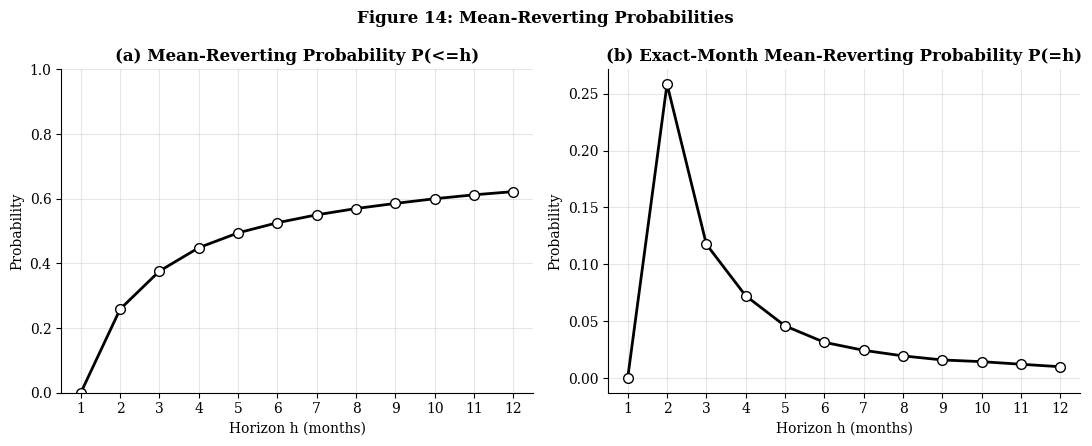

Figure 14 saved.


In [9]:
# ── Figure 14: Plot ───────────────────────────────────────────────
hs = np.arange(1, H_MAX + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(hs, p_within, "o-", color="black", linewidth=2,
         markersize=7, markerfacecolor="white")
ax1.set_xlabel("Horizon h (months)")
ax1.set_ylabel("Probability")
ax1.set_title("(a) Mean-Reverting Probability P(<=h)", fontweight="bold")
ax1.set_xticks(hs)
ax1.set_xlim(0.5, H_MAX + 0.5)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

ax2.plot(hs, p_exact, "o-", color="black", linewidth=2,
         markersize=7, markerfacecolor="white")
ax2.set_xlabel("Horizon h (months)")
ax2.set_ylabel("Probability")
ax2.set_title("(b) Exact-Month Mean-Reverting Probability P(=h)", fontweight="bold")
ax2.set_xticks(hs)
ax2.set_xlim(0.5, H_MAX + 0.5)
ax2.grid(True, alpha=0.3)

fig.suptitle("Figure 14: Mean-Reverting Probabilities",
             fontsize=12, fontweight="bold")
plt.tight_layout()
save_figure(fig, "Figure14_Mean_Reverting_Probability")
plt.show()
print("Figure 14 saved.")

In [10]:
# ── Table 7: Freshness regression ────────────────────────────────
# Freshness = 1 - |current month firms ∩ next month firms| / |current month firms|
# i.e. the fraction of this month's cluster members that are gone next month.
# Matches freshness.ipynb reference exactly.

print("Computing freshness per (year_month, cluster)...")
records = []
for cl, grp in firm.groupby("cluster_ranked"):
    grp    = grp.sort_values("year_month")
    months = grp["year_month"].unique()
    sets   = {m: set(grp[grp["year_month"] == m]["permno"]) for m in months}
    for i in range(len(months) - 1):
        cur, nxt = months[i], months[i + 1]
        if sets[cur]:
            fresh = 1 - len(sets[cur] & sets[nxt]) / len(sets[cur])
            records.append({"cluster_ranked": cl,
                             "year_month":     cur,
                             "freshness":      fresh})

freshness = pd.DataFrame(records)
print(f"Freshness panel: {freshness.shape}")
print(freshness.head(3).to_string())

Computing freshness per (year_month, cluster)...
Freshness panel: (26345, 3)
  cluster_ranked year_month  freshness
0            L01    1977-01   0.175000
1            L01    1977-02   0.278481
2            L01    1977-03   0.114286


In [11]:
# ── Merge freshness with next-month cluster return ─────────────────
# r_t1 = 1-month-ahead VW excess return (the correct forward return)
ret_long = df_cl[["year_month", "cluster", "r_t1"]].copy()
ret_long["cluster_ranked"] = ret_long["cluster"].map(rank_map)
ret_long["date"] = pd.to_datetime(ret_long["year_month"], format="%Y-%m")
ret_long["year_month_next"] = (
    ret_long["date"] + pd.DateOffset(months=1)
).dt.strftime("%Y-%m")

panel = freshness.merge(
    ret_long[["year_month_next", "cluster_ranked", "r_t1"]].rename(
        columns={"year_month_next": "year_month", "r_t1": "ret_next"}
    ),
    on=["year_month", "cluster_ranked"],
    how="inner"
).dropna(subset=["freshness", "ret_next"])

panel["time_id"]    = panel["year_month"].astype(str)
panel["cluster_id"] = panel["cluster_ranked"].astype(str)

print(f"Regression panel: {panel.shape}")
print(f"Period: {panel['year_month'].min()}  ->  {panel['year_month'].max()}")

Regression panel: (25791, 6)
Period: 1977-02  ->  2020-01


In [12]:
# ── TWFE regression ────────────────────────────────────────────────
def twfe_reg(y, x, time_id, cluster_id):
    df_r = pd.DataFrame({"y": y, "x": x, "t": time_id, "c": cluster_id}).dropna()
    df_r["y"] -= df_r.groupby("t")["y"].transform("mean")
    df_r["y"] -= df_r.groupby("c")["y"].transform("mean")
    df_r["x"] -= df_r.groupby("t")["x"].transform("mean")
    df_r["x"] -= df_r.groupby("c")["x"].transform("mean")
    X   = sm.add_constant(df_r["x"].values)
    res = sm.OLS(df_r["y"].values, X).fit(
        cov_type="cluster", cov_kwds={"groups": df_r["c"].values}
    )
    return res.params[1], res.bse[1], res.tvalues[1], len(df_r), res.rsquared

coef1, se1, t1, n1, r2_1 = twfe_reg(
    panel["ret_next"], panel["freshness"],
    panel["time_id"],  panel["cluster_id"]
)

table7 = pd.DataFrame({
    "(1)": [
        f"{coef1:.4f}{stars(t1)}",
        f"({t1:.2f})",
        "No", "Yes", "Yes",
        f"{r2_1:.4f}",
        f"{n1:,}",
    ],
}, index=["Freshness", "t-stat", "Controls", "Time FE", "Cluster FE", "R2", "N"])

print("=== Table 7 ===")
print(table7.to_string())
print(f"\nPaper: coef=0.0167***, t=6.15")
print(f"Ours : coef={coef1:.4f}, t={t1:.2f}")
save_table(table7, "Table7_Freshness_Regression")
print("Table 7 saved.")

=== Table 7 ===
                (1)
Freshness   -0.0004
t-stat      (-0.07)
Controls         No
Time FE         Yes
Cluster FE      Yes
R2           0.0000
N            25,791

Paper: coef=0.0167***, t=6.15
Ours : coef=-0.0004, t=-0.07
  Saved → output/tables/Table7_Freshness_Regression.{csv,tex}
Table 7 saved.
